<a href="https://colab.research.google.com/github/sutanaruan-alt/ADABOOST-Kelompok2/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#kelompok 2
#Sutan Aruan, Niko silaban, Bonando Lumban Gaol, Michael Hutagalung
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Membaca data menggunakan jalur folder Colab yang tepat
df = pd.read_csv('/content/online_shoppers_intention.csv')

# Menampilkan 5 baris data teratas
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
#kelompok 2
#Sutan Aruan, Niko silaban, Bonando Lumban Gaol, Michael Hutagalung

# 1. Memeriksa informasi umum dataset (jumlah baris, kolom, dan tipe data)
print("--- Informasi Dataset ---")
df.info()

# 2. Memeriksa apakah ada data yang kosong (null/missing values)
print("\n--- Jumlah Data yang Kosong per Kolom ---")
print(df.isnull().sum())

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 

/tmp/ipykernel_599/320578011.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='Set2')


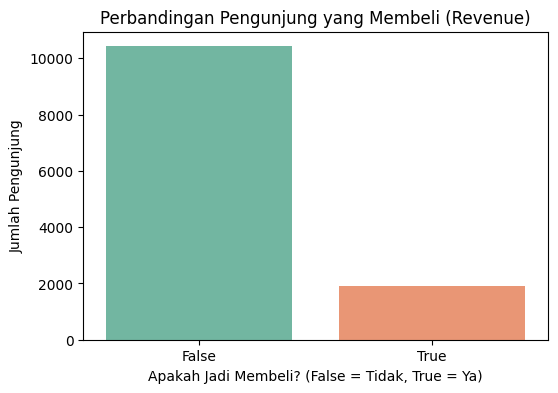

In [ ]:
#kelompok 2
#Sutan Aruan, Niko silaban, Bonando Lumban Gaol, Michael Hutagalung

# Membuat visualisasi perbandingan jumlah pengunjung yang membeli vs tidak
plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df, palette='Set2')
plt.title('Perbandingan Pengunjung yang Membeli (Revenue)')
plt.xlabel('Apakah Jadi Membeli? (False = Tidak, True = Ya)')
plt.ylabel('Jumlah Pengunjung')
plt.show()

In [ ]:
 #kelompok 2
#Sutan Aruan, Niko silaban, Bonando Lumban Gaol, Michael Hutagalung

# Menghapus kolom bulan karena variasi teksnya terlalu banyak untuk simplifikasi praktikum
df_clean = df.drop(columns=['Month'])

# Mengubah kolom teks (VisitorType, Weekend, Revenue) menjadi angka binari/numerik
df_clean = pd.get_dummies(df_clean, columns=['VisitorType'], drop_first=True)
df_clean['Weekend'] = df_clean['Weekend'].astype(int)
df_clean['Revenue'] = df_clean['Revenue'].astype(int)

# Memisahkan Fitur (X) dan Target/Label yang mau ditebak (y)
X = df_clean.drop(columns=['Revenue'])
y = df_clean['Revenue']

# Membagi data menjadi Data Training (80%) dan Data Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. MELATIH MODEL 1: LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 3. MELATIH MODEL 2: ADABOOST CLASSIFIER
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)

# 4. MENAMPILKAN HASIL EVALUASI AKURASI KEDUA MODEL
print("======= HASIL EVALUASI MODEL MACHINE LEARNING =======")
print(f"Akurasi Model Logistic Regression : {accuracy_score(y_test, lr_pred) * 100:.2f}%")
print(f"Akurasi Model AdaBoost Classifier : {accuracy_score(y_test, ada_pred) * 100:.2f}%")
print("=====================================================")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


======= HASIL EVALUASI MODEL MACHINE LEARNING =======
Akurasi Model Logistic Regression : 86.78%
Akurasi Model AdaBoost Classifier : 88.16%


In [ ]:
#kelompok 2
#Sutan Aruan, Niko silaban, Bonando Lumban Gaol, Michael Hutagalung

# Menyiapkan 1 data pengunjung baru dengan pas 17 kolom/angka sesuai kebutuhan AI
# Tambah satu angka 0 di ujung untuk memenuhi jumlah kolom VisitorType
data_pengunjung_baru = [[3, 45.0, 0, 0.0, 10, 200.0, 0.0, 0.02, 20.0, 0.0, 1, 1, 1, 1, 1, 0, 0]]

# Menyuruh AI AdaBoost menebak hasil data baru
tebakan_ai = ada_model.predict(data_pengunjung_baru)

print("======= UJI COBA OTAK AI =======")
if tebakan_ai[0] == 1:
    print("Hasil Tebakan AI: Pengunjung ini AKAN MEMBELI produk! (Revenue = True)")
else:
    print("Hasil Tebakan AI: Pengunjung ini CUMA LIHAT-LIHAT saja. (Revenue = False)")
print("================================")

======= UJI COBA OTAK AI =======
Hasil Tebakan AI: Pengunjung ini AKAN MEMBELI produk! (Revenue = True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


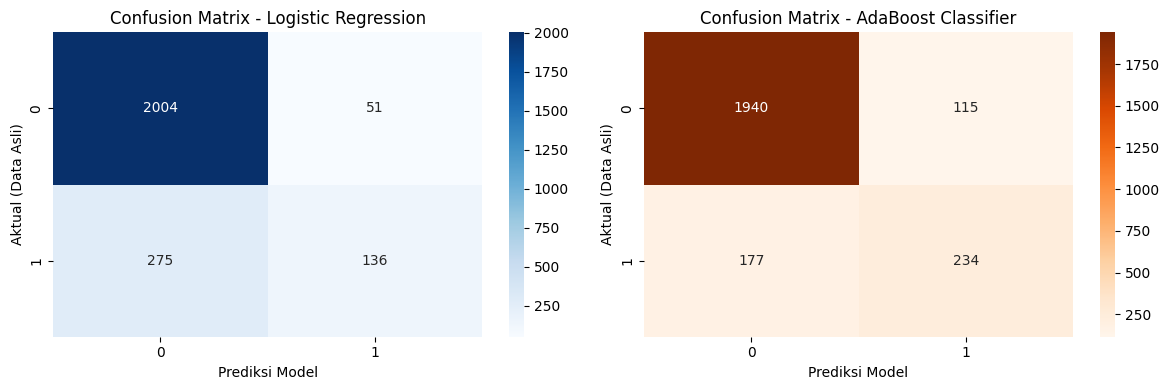

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Menghitung Confusion Matrix untuk kedua model
cm_lr = confusion_matrix(y_test, lr_pred)
cm_ada = confusion_matrix(y_test, ada_pred)

# 2. Membuat plot visualisasi berdampingan
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot untuk Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Logistic Regression')
ax[0].set_ylabel('Aktual (Data Asli)')
ax[0].set_xlabel('Prediksi Model')

# Plot untuk AdaBoost
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Confusion Matrix - AdaBoost Classifier')
ax[1].set_ylabel('Aktual (Data Asli)')
ax[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()